# Exercises 1b: PCA

In [53]:
import numpy as np
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
from sklearn import decomposition

## Exercise 1

In [17]:
txt_name = 'irisdata.txt'
in_dir = 'data/'

In [18]:
iris_data = np.loadtxt(in_dir + txt_name, comments="%")
# x is a matrix with 50 rows and 4 columns
x = iris_data[0:50, 0:4]

In [19]:
n_feat = x.shape[1]
n_obs = x.shape[0]
print(f"Number of features: {n_feat} and number of observations: {n_obs}")

Number of features: 4 and number of observations: 50


## Exercise 2

In [20]:
sep_l = x[:, 0]
sep_w = x[:, 1]
pet_l = x[:, 2]
pet_w = x[:, 3]

In [21]:
# Use ddof = 1 to make an unbiased estimate
var_sep_l = sep_l.var(ddof=1)
var_sep_w = sep_w.var(ddof=1)
var_pet_l = pet_l.var(ddof=1)
var_pet_w = pet_w.var(ddof=1)

print(f"Variance of sepal length: {var_sep_l:.2f}")
print(f"Variance of sepal width: {var_sep_w:.2f}")
print(f"Variance of petal length: {var_pet_l:.2f}")
print(f"Variance of petal width: {var_pet_w:.2f}")

Variance of sepal length: 0.12
Variance of sepal width: 0.14
Variance of petal length: 0.03
Variance of petal width: 0.01


## Exercise 3

$$\sigma^2 = \frac{1}{N-1} \sum_i a_i b_i$$

In [22]:
# Uncentered covariance

cov_sep_l_pet_l = (1 / (n_obs - 1)) * np.sum(sep_l * pet_l)
print(f"Covariance between sepal length and petal length: {cov_sep_l_pet_l:.2f}")

Covariance between sepal length and petal length: 7.48


In [23]:
# Uncentered covariance

cov_sep_l_sep_w = (1 / (n_obs - 1)) * np.sum(sep_l * sep_w)
print(f"Covariance between sepal length and sepal width: {cov_sep_l_sep_w:.2f}")

Covariance between sepal length and sepal width: 17.61


## Exercise 4

<Figure size 640x480 with 0 Axes>

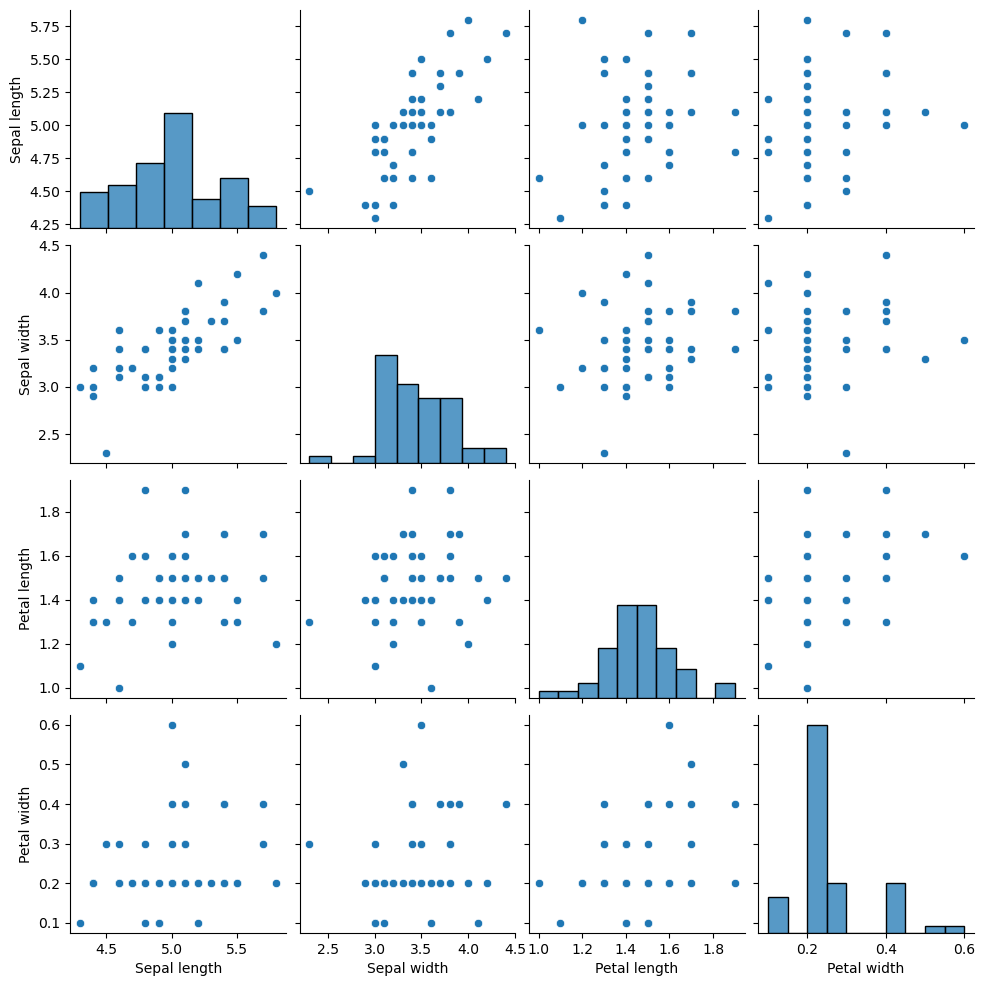

In [27]:
plt.figure() # Added this to make sure that the figure appear

# Transform the data into a Pandas dataframe
d = pd.DataFrame(x, columns=['Sepal length', 'Sepal width',
							 'Petal length', 'Petal width'])
sns.pairplot(d)
plt.show()

In [28]:
# Correlation matrix to quantify pair relationships
corr = d.corr()
print(corr.round(2))

              Sepal length  Sepal width  Petal length  Petal width
Sepal length          1.00         0.74          0.27         0.28
Sepal width           0.74         1.00          0.18         0.23
Petal length          0.27         0.18          1.00         0.33
Petal width           0.28         0.23          0.33         1.00


What measurements are related and which ones are not-related? Can you recognise the results you found, when you computed the variance and covariance?

*ANSWER:*

Related:
- Sepal width & sepal length (strong relation)
- Petal length & petal width (weak relation)

## PCA Analysis

### Exercise 5

$$\mathbf{C}_\mathbf{X} = \frac{1}{N-1} \mathbf{X}^\text{T} \mathbf{X}$$

In [29]:
mn = np.mean(x, axis=0)
data = x - mn

In [30]:
cov_x = (1 / (n_obs - 1)) * np.matmul(data.T, data)
print(cov_x)

[[0.12424898 0.09921633 0.0163551  0.01033061]
 [0.09921633 0.1436898  0.01169796 0.00929796]
 [0.0163551  0.01169796 0.03015918 0.00606939]
 [0.01033061 0.00929796 0.00606939 0.01110612]]


In [ ]:
cov_x_np = np.cov(data, rowvar=False) # rowvar=False to get features as columns
print(cov_x_np)

[[0.12424898 0.09921633 0.0163551  0.01033061]
 [0.09921633 0.1436898  0.01169796 0.00929796]
 [0.0163551  0.01169796 0.03015918 0.00606939]
 [0.01033061 0.00929796 0.00606939 0.01110612]]


### Exercise 6

In [35]:
values, vectors = np.linalg.eig(cov_x)
print('Eigenvalues:', values)
print('Eigenvectors (principal components):', '\n', vectors)

Eigenvalues: [0.23645569 0.03691873 0.0267964  0.00903326]
Eigenvectors (principal components): 
 [[-0.6690784  -0.59788401  0.43996277 -0.03607712]
 [-0.73414783  0.62067342 -0.27460747 -0.01955027]
 [-0.0965439  -0.49005559 -0.8324495  -0.23990129]
 [-0.06356359 -0.13093791 -0.19506751  0.96992969]]


### Exercise 7

First try to find out how much of the total variation the first component explains?

In [40]:
sorted_values = np.sort(values)[::-1] # Sort in descending order
pc1_expl_var = sorted_values[0] / np.sum(sorted_values)
print(f"Proportion of variance explained by the first principal component: {pc1_expl_var:.2f}")

Proportion of variance explained by the first principal component: 0.76


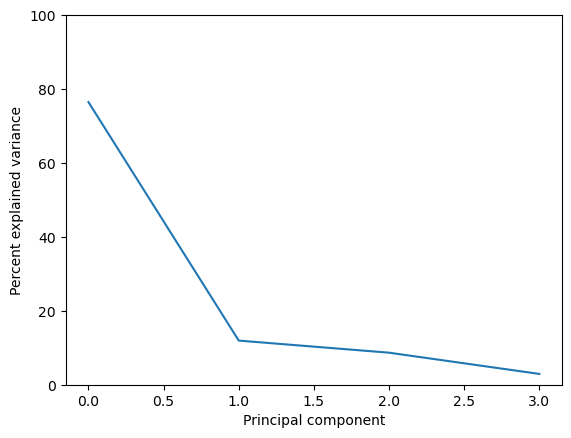

In [42]:
v_norm = values / values.sum() * 100
plt.plot(v_norm)
plt.xlabel('Principal component')
plt.ylabel('Percent explained variance')
plt.ylim([0, 100])

plt.show()

### Exercise 8

In [50]:
# Projected data onto the the PCA space
pc_proj = vectors.T.dot(data.T)
pc_proj_T = pc_proj.T
print(pc_proj_T.shape)

(50, 4)


<Figure size 640x480 with 0 Axes>

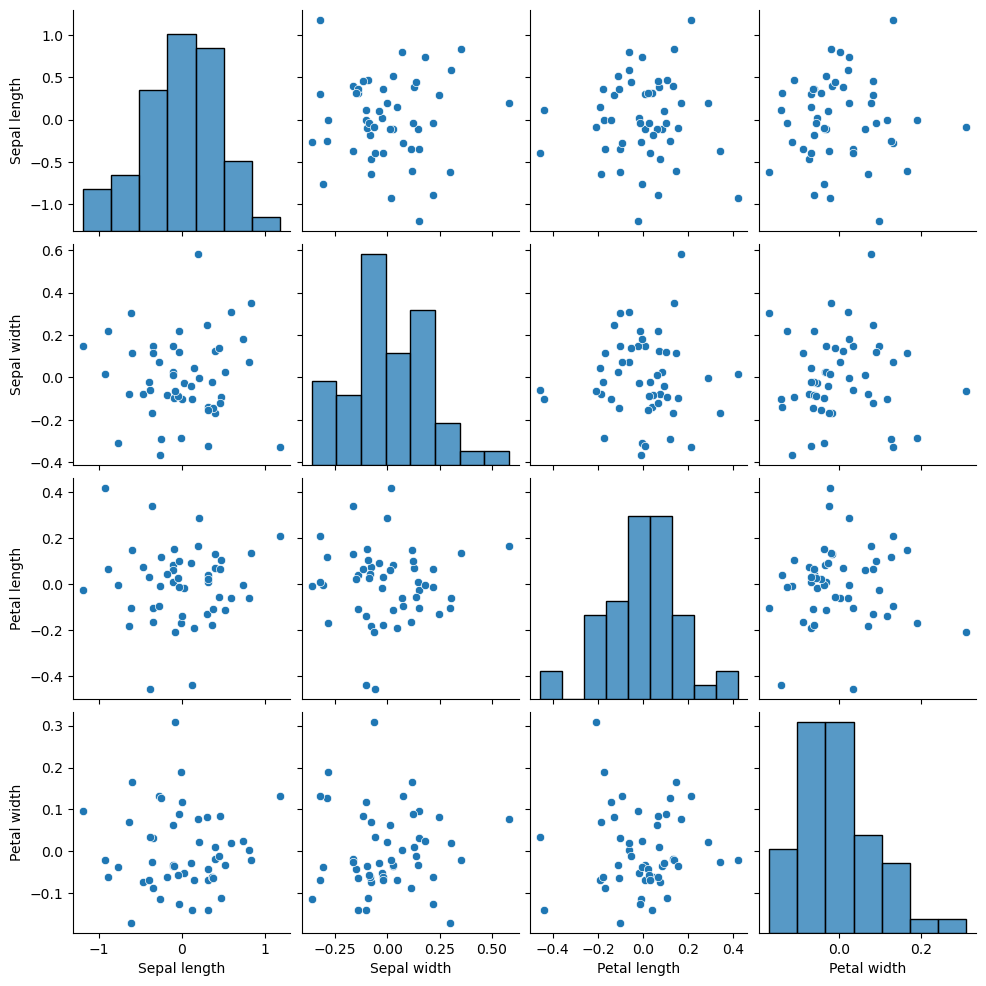

In [51]:
# Pairplot with the projected data
plt.figure()

d_proj = pd.DataFrame(pc_proj_T, columns=['Sepal length', 'Sepal width',
							 'Petal length', 'Petal width'])
sns.pairplot(d_proj)
plt.show()

### Exercise 9: Direct PCA using the decompositions functions (sci-kit learn)

In [54]:
pca = decomposition.PCA()
pca.fit(x)
values_pca = pca.explained_variance_
exp_var_ratio = pca.explained_variance_ratio_
vectors_pca = pca.components_

data_transform = pca.transform(x)

In [55]:
print('Eigenvalues:', values_pca)
print('Explained variance ratio:', exp_var_ratio)
print('Eigenvectors (principal components):', '\n', vectors_pca)

Eigenvalues: [0.23645569 0.03691873 0.0267964  0.00903326]
Explained variance ratio: [0.7647237  0.11939924 0.0866625  0.02921456]
Eigenvectors (principal components): 
 [[ 0.6690784   0.73414783  0.0965439   0.06356359]
 [-0.59788401  0.62067342 -0.49005559 -0.13093791]
 [-0.43996277  0.27460747  0.8324495   0.19506751]
 [-0.03607712 -0.01955027 -0.23990129  0.96992969]]


Compare the results from the results you found using the step-by-step procedure. Some of the results are transposed - which ones?

*ANSWER*:

The eigenvectors are transposed with respect to the first approach ("manually" combining different steps).